# I. Installation des librairies

Installation des librairies à partir du fichier `requirements.txt`

# II. Importation des libairies

In [92]:
# Manipulation des données
import numpy as np
import pandas as pd

# Visualitation
import seaborn as sns
import matplotlib.pyplot as plt

# Modèles de régression
from sklearn.preprocessing import StandardScaler

# Répertoire de travail et gestion d'erreur
import os

In [78]:
# Importation du package frenezik : Simulation et régressions régularisées
from frenezik import Residuals, TargetPredictors, Regularization

# III. Définition du repertoire de travail

In [79]:
# Définition du repertoire de travail
chemin = r"C:\..."
mkdir_data = "data"
mkdir_graphics = "graphics"

# Création des dossiers
try :
    # Définir le repertoire de travail
    os.chdir(chemin)

    # Création du dossier pour les graphiques
    os.mkdir(mkdir_data)

    # Création du dossier pour les bases de données
    os.mkdir(mkdir_graphics)

except FileExistsError:
    print("L'un des dossiers existe déjà")

L'un des dossiers existe déjà


In [85]:
# Chargement de la base de données
data_california = pd.read_csv(r"data\\housing.csv", nrows=500)
data_california.dropna(inplace=True)
data_california.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


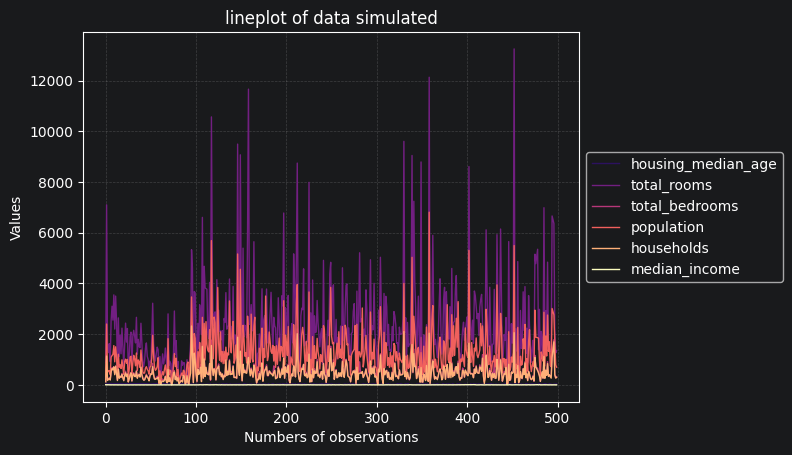

In [86]:
# Courbe
TarPred = TargetPredictors(population_size=1, true_coefficients=[0,1])
TarPred.Visualization_X_y(data_simulated=data_california.iloc[:, 2:-2], figure='lineplot')

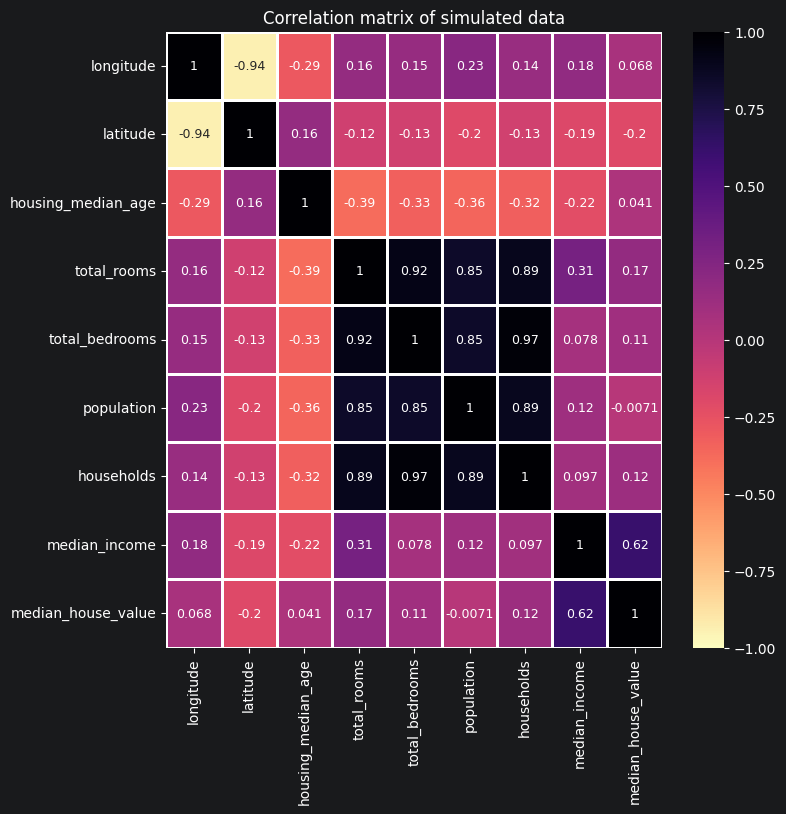

In [87]:
# Matrice de correlation
plt.figure(figsize=(8,8))
TarPred.Visualization_X_y(data_simulated=data_california.select_dtypes(include=['float', 'int']), figure='correlation_matrix')

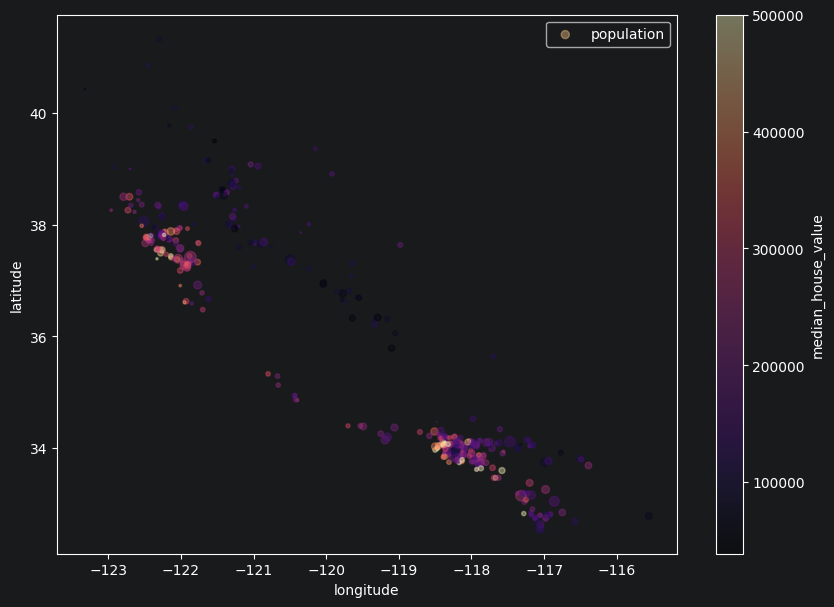

In [88]:
# Analyse spatiale
data_california.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
    s=data_california["population"]/100, label="population", figsize=(10,7),
    c="median_house_value", cmap=plt.get_cmap("magma"), colorbar=True,
    sharex=False)
plt.legend()
plt.show()

In [200]:
# Variable à prédire
Target = np.array(data_california['median_house_value']).reshape(-1, 1)
Target_scaled =  scaler.fit_transform(Target)

# Variables prédictives
Predictors = data_california.drop(['median_house_value', 'ocean_proximity'], axis=1)

# StandardScaler avec std = True et mean=False
scaler = StandardScaler(with_mean=False, with_std=True)
Predictors_scaled =  pd.DataFrame(scaler.fit_transform(Predictors), columns=Predictors.columns.tolist())

In [214]:
# Données standardisées
Target_df = pd.DataFrame({'median_house_value': Target_scaled.ravel()})
df_california_scaled = pd.concat([Target_df, Predictors_scaled], axis=1)
df_california_scaled.to_csv(f'{mkdir_data}/housing_scaled.csv', index = False)

## VII.1 Valeur unique de $\alpha$

In [217]:
# Valeur du facteur de pénalité (alpha)
AlphaValue = 5

# Intercept du modèle
InterceptState = False

# Random seed
RandomSeed = 1980

# Instanciation de la fonction de régularisation
Regul = Regularization(predictors=Predictors,
                       target=Target,
                       alpha=AlphaValue,
                       intercept=InterceptState,
                       random_seed=RandomSeed)

# Résumé des coefficients pénalisés en fonction du paramètre alpha
ResultsRidge = Regul.Penalized_Regression(model='ridge')
ResultsRidge

,Variables,Estimators,Std.error,T.stats,P.vals
0,longitude,-43091.520204,4912.337687,8.772101,2.000000e-16
1,latitude,-46571.857640,4780.952797,9.741125,2.000000e-16
2,housing_median_age,532.672330,275.704063,1.932044,5.335410e-02
3,total_rooms,-9.277987,6.305211,1.471479,1.411616e-01
4,total_bedrooms,52.879663,52.041282,1.016110,3.095770e-01
5,population,-63.223110,8.930652,7.079339,1.448397e-12
6,households,170.882502,53.890577,3.170916,1.519590e-03
7,median_income,41146.497665,2470.291960,16.656532,2.000000e-16


## VII.2 Etude du chemin de régularisation ( $\alpha_k$ )

In [171]:
# Intervalle du facteur de pénalité (alpha)
AlphaList = np.round(np.log(np.linspace(1, 9, 19)),1)

# Intercept du modèle
InterceptState = False

# Instanciation de la fonction de régularisation
Regul = Regularization(predictors=Predictors_scaled,
                       target=Target_scaled,
                       alpha=AlphaList,
                       intercept=InterceptState,
                       random_seed=RandomSeed)

# Résumé des coefficients pénalisés en fonction du paramètre alpha
SummaryCoefRidge = Regul.Penalized_Regression(model='ridge')
SummaryCoefRidge

,Variables,0.0,0.4,0.6,0.8,1.0,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,2.0,2.1,2.2
0,longitude,-0.070641,-0.070361,-0.070232,-0.070109,-0.069992,-0.069880,-0.069827,-0.069774,-0.069722,-0.069672,-0.069623,-0.069575,-0.069528,-0.069481,-0.069436,-0.069392
1,latitude,-0.233720,-0.232844,-0.232433,-0.232039,-0.231661,-0.231297,-0.231120,-0.230946,-0.230776,-0.230608,-0.230443,-0.230281,-0.230122,-0.229965,-0.229811,-0.229659
2,housing_median_age,0.171159,0.171430,0.171554,0.171671,0.171781,0.171884,0.171933,0.171981,0.172028,0.172073,0.172116,0.172159,0.172200,0.172240,0.172279,0.172316
3,total_rooms,-0.188844,-0.190312,-0.190864,-0.191308,-0.191652,-0.191904,-0.191999,-0.192073,-0.192127,-0.192163,-0.192181,-0.192182,-0.192166,-0.192134,-0.192086,-0.192024
4,total_bedrooms,0.009467,0.024023,0.030710,0.037039,0.043036,0.048724,0.051458,0.054122,0.056719,0.059251,0.061719,0.064127,0.066475,0.068766,0.071001,0.073183
5,population,-0.585919,-0.579554,-0.576525,-0.573590,-0.570741,-0.567974,-0.566620,-0.565284,-0.563967,-0.562666,-0.561383,-0.560116,-0.558865,-0.557629,-0.556408,-0.555203
6,households,0.768535,0.749578,0.740660,0.732082,0.723821,0.715858,0.711982,0.708173,0.704431,0.700751,0.697133,0.693575,0.690075,0.686632,0.683243,0.679907
7,median_income,0.670180,0.670213,0.670178,0.670112,0.670017,0.669897,0.669827,0.669752,0.669671,0.669585,0.669493,0.669397,0.669296,0.669190,0.669080,0.668965


<Figure size 1000x1000 with 0 Axes>

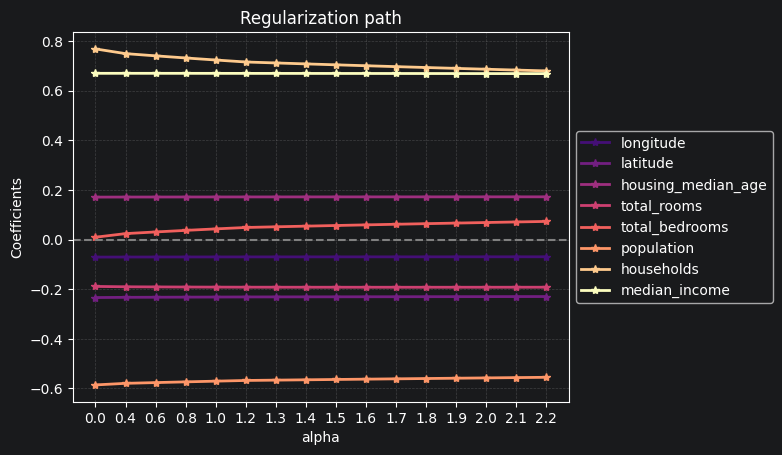

In [172]:
# Visualisation de l'effet de rétrécissement selon une approche par courbe
plt.figure(figsize=(10, 10))
Regul.Visualization_Shrinking(penalized_coefficients_table=SummaryCoefRidge,
                              variables_selected=None, # non utilisé lorsque figure = "curve"
                              alpha_value_selected=None, # non utilisé lorsque figure = "curve"
                              figure='curve')

## VII.3 Analyse des résidus de régression

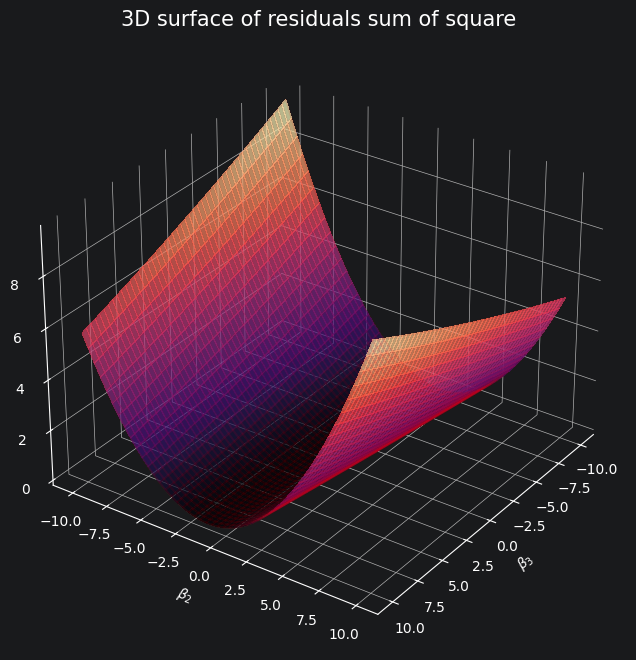

In [173]:
# Surface pour visualiser les residus estimés en fonction des paramètres B1 et B2 simulés
Beta1 = np.linspace(-10, 10, 50)
Beta2 = np.linspace(-10, 10, 50)
Regul.Visualization_Residuals(list_beta_1=Beta1,
                        list_beta_2=Beta2,
                        predictors=Predictors_scaled,
                        target=Target_scaled,
                        penalized_coefficients_table=SummaryCoefRidge,
                        var_1='housing_median_age',
                        var_2='latitude',
                        intercept=0,
                        figure='surface3D')

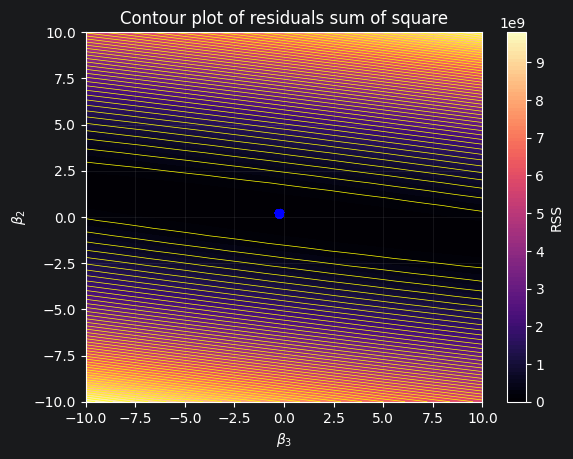

In [174]:
# Carte de niveau pour visualiser les residus estimés en fonction des paramètres B1 et B2 simulés
Beta1 = np.linspace(-10, 10, 50)
Beta2 = np.linspace(-10, 10, 50)
Regul.Visualization_Residuals(list_beta_1=Beta1,
                        list_beta_2=Beta2,
                        predictors=Predictors_scaled,
                        target=Target_scaled,
                        penalized_coefficients_table=SummaryCoefRidge,
                        var_1='housing_median_age',
                        var_2='latitude',
                        intercept=0,
                        figure='contour_map')

# VIII. Régression Régularisée LASSO

## VIII.1 Valeur unique de $\alpha$

In [175]:
# Valeur du facteur de pénalité (alpha)
AlphaValue = 5.0

# Intercept du modèle
InterceptState = False

# Instanciation de la fonction de régularisation
Regul = Regularization(predictors=Predictors_scaled,
                       target=Target_scaled,
                       alpha=AlphaValue,
                       intercept=InterceptState,
                       random_seed=RandomSeed)

# Résumé des coefficients pénalisés en fonction du paramètre alpha
ResultsLasso = Regul.Penalized_Regression(model='lasso')
ResultsLasso

,Variables,Estimators
0,longitude,-0.029638
1,latitude,0.000000
2,housing_median_age,0.000000
3,total_rooms,0.000000
4,total_bedrooms,0.000000
5,population,0.000000
6,households,0.000000
7,median_income,0.000000


## VIII.2 Etude du chemin de régularisation ( $\alpha_k$ )

In [176]:
# Intervalle du facteur de pénalité (alpha)
AlphaList = np.round(np.log(np.linspace(1, 9, 19)),1)

# Intercept du modèle
InterceptState = False

# Instanciation de la fonction de régularisation
Regul = Regularization(predictors=Predictors_scaled,
                       target=Target_scaled,
                       alpha=AlphaList,
                       intercept=InterceptState,
                       random_seed=RandomSeed)

# Résumé des coefficients pénalisés en fonction du paramètre alpha
SummaryCoefLasso = Regul.Penalized_Regression(model='lasso')
SummaryCoefLasso

,Variables,0.0,0.4,0.6,0.8,1.0,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,2.0,2.1,2.2
0,longitude,-0.070641,-0.022916,-0.029422,-0.030883,-0.030824,-0.030765,-0.030735,-0.030705,-0.030676,-0.030646,-0.030617,-0.030587,-0.030557,-0.030528,-0.030498,-0.030468
1,latitude,-0.233720,-0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,housing_median_age,0.171159,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,total_rooms,-0.188844,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,total_bedrooms,0.009467,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,population,-0.585919,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,households,0.768535,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,median_income,0.670180,0.234583,0.044126,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


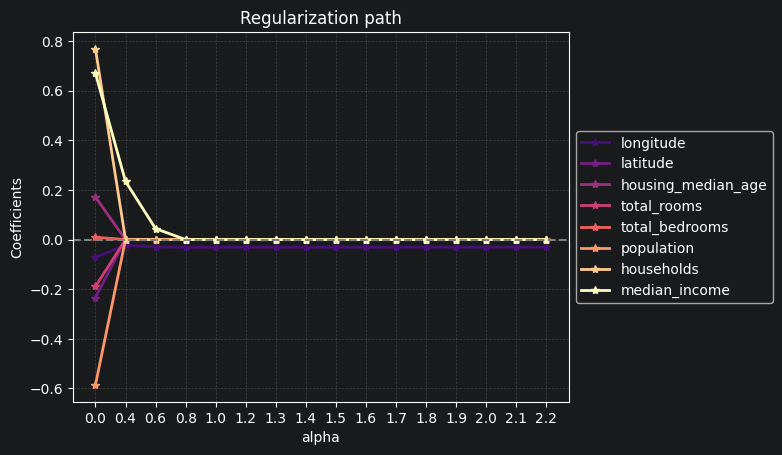

In [177]:
# Visualisation de l'effet de rétrécissement selon une approche par courbe
Regul.Visualization_Shrinking(penalized_coefficients_table=SummaryCoefLasso,
                              variables_selected=None, # non utilisé lorsque figure = "curve"
                              alpha_value_selected=None, # non utilisé lorsque figure = "curve"
                              figure='curve')

## VIII.2 Analyse des résidus de régression

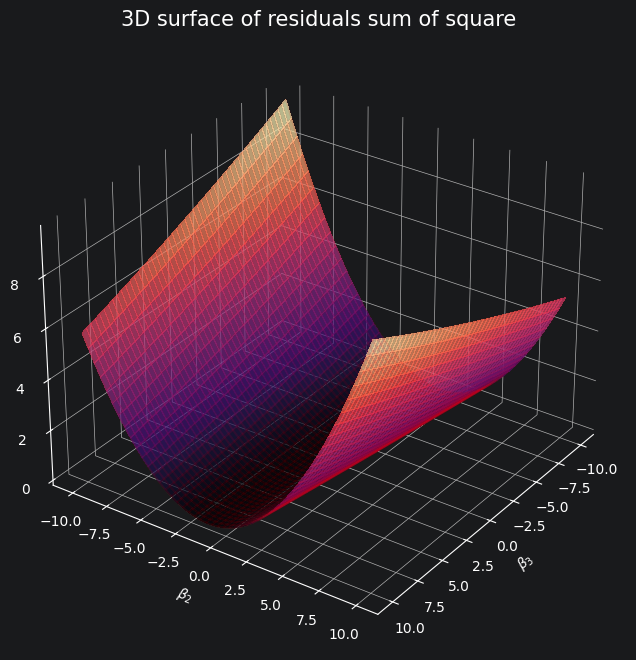

In [179]:
# Surface pour visualiser les residus estimés en fonction des paramètres B1 et B2 simulés
Beta1 = np.linspace(-10, 10, 50)
Beta2 = np.linspace(-10, 10, 50)
Regul.Visualization_Residuals(list_beta_1=Beta1,
                        list_beta_2=Beta2,
                        predictors=Predictors_scaled,
                        target=Target_scaled,
                        penalized_coefficients_table=SummaryCoefLasso,
                        var_1='housing_median_age',
                        var_2='latitude',
                        intercept=0,
                        figure='surface3D')

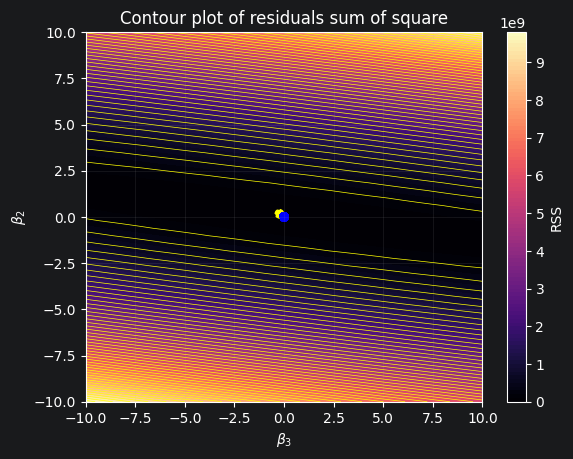

In [181]:
# Carte de niveau pour visualiser les residus estimés en fonction des paramètres B1 et B2 simulés
Beta1 = np.linspace(-10, 10, 50)
Beta2 = np.linspace(-10, 10, 50)
Regul.Visualization_Residuals(list_beta_1=Beta1,
                        list_beta_2=Beta2,
                        predictors=Predictors_scaled,
                        target=Target_scaled,
                        penalized_coefficients_table=SummaryCoefLasso,
                        var_1='housing_median_age',
                        var_2='latitude',
                        intercept=0,
                        figure='contour_map')

In [182]:
# Synthèse des coefficients de régression
list_estimators_names =  SummaryCoefRidge['Variables']
list_estimators_mco_values = SummaryCoefRidge['0.0']
list_estimators_ridge_values = SummaryCoefRidge['0.4']
list_estimators_lasso_values = SummaryCoefLasso['0.4']
df_barplot = pd.DataFrame({
    'variables' : list_estimators_names,
    'mco': list_estimators_mco_values,
    'ridge': list_estimators_ridge_values,
    'lasso':list_estimators_lasso_values
})
df_barplot

,variables,mco,ridge,lasso
0,longitude,-0.070641,-0.070361,-0.022916
1,latitude,-0.233720,-0.232844,-0.000000
2,housing_median_age,0.171159,0.171430,0.000000
3,total_rooms,-0.188844,-0.190312,0.000000
4,total_bedrooms,0.009467,0.024023,0.000000
5,population,-0.585919,-0.579554,-0.000000
6,households,0.768535,0.749578,0.000000
7,median_income,0.670180,0.670213,0.234583


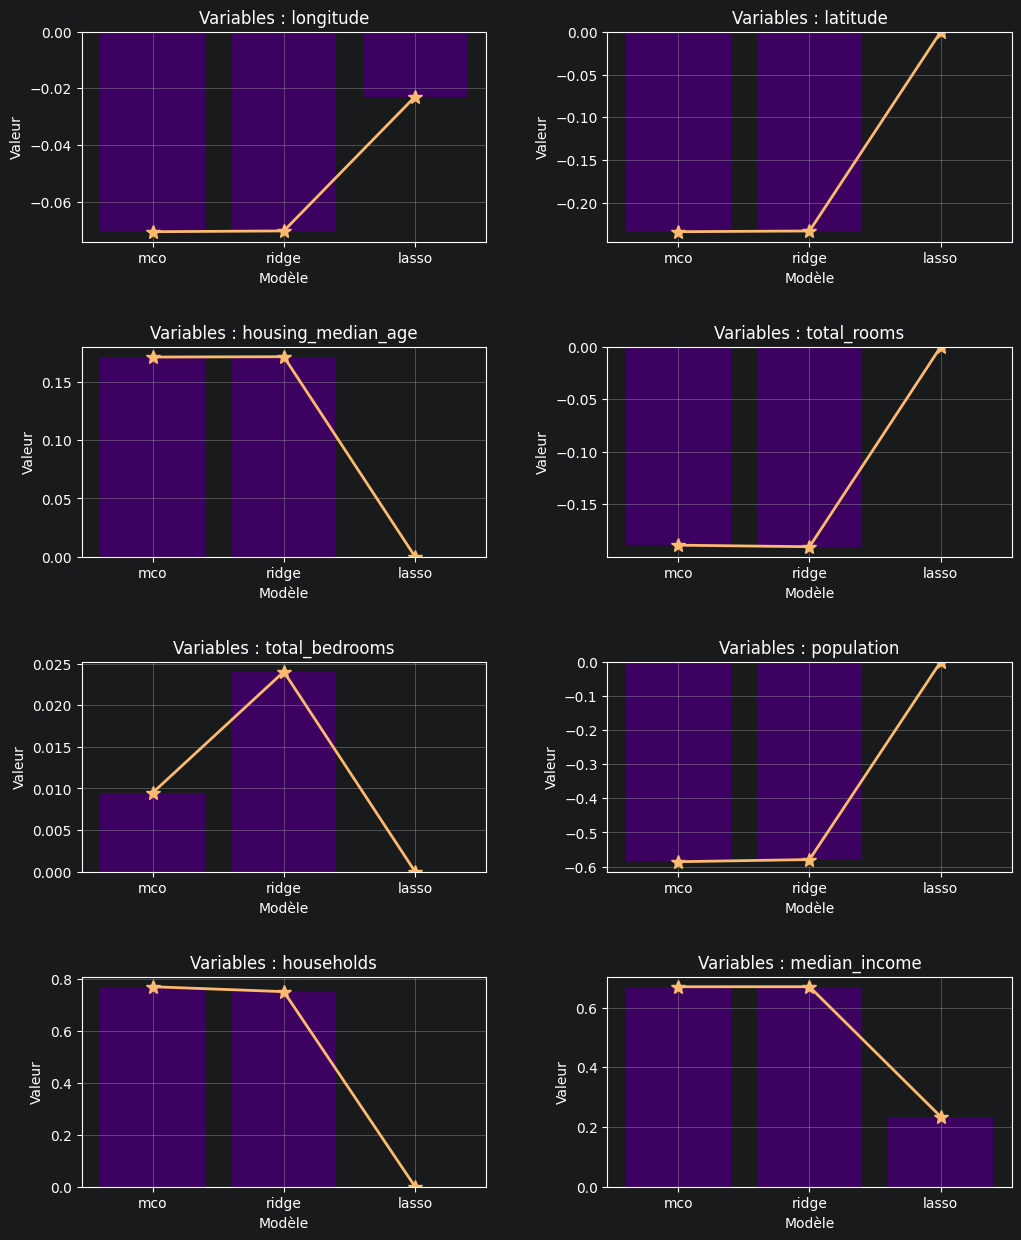

In [187]:
# Visualisation de l'effet de retrecissement
import matplotlib.pyplot as plt

fig, ax = plt.subplots(4, 2, figsize=(12, 15))
axs = ax.flatten()

for i, estimators in enumerate(df_barplot['variables']):
    estimators_names = df_barplot.columns[1:]
    estimators_values = df_barplot.loc[df_barplot['variables'].isin([estimators]), estimators_names].values[0]

    axs[i].bar(estimators_names, estimators_values, color='#3d0261', align='center', capsize=10)
    axs[i].plot(estimators_names, estimators_values, color='#fbba6d', marker='*', linewidth=2, ms=10)

    axs[i].set_xlabel('Modèle')
    axs[i].set_ylabel("Valeur")
    axs[i].set_title(f"Variables : {estimators}")
    axs[i].grid(True)

plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.show()